In [1]:
import conntility
import numpy
import pandas

from scipy.spatial import distance

fn = "/Users/mwr/Documents/artefacts/connectomes/Human connectivity paper/Shapson_Coe_et_al_human_all_somas.h5"
M = conntility.ConnectivityMatrix.from_h5(fn, "compressed")

types_of_interest = [
    "PYRAMIDAL",
    "INTERNEURON",
    "SPINY_ATYPICAL",
    "UNCLASSIFIED_NEURON",
    "SPINY_STELLATE"
]
N = M.index("celltype").isin(types_of_interest)

N.vertices["celltype"].value_counts()

celltype
PYRAMIDAL              8520
INTERNEURON            4469
SPINY_ATYPICAL         1479
UNCLASSIFIED_NEURON     667
SPINY_STELLATE          190
Name: count, dtype: int64

In [ ]:
xyz = ["x", "y", "z"]
full_res = numpy.array([ 8, 8, 33 ]) # voxel resultion in nm

for _col, _fac in zip(xyz, full_res):
    N.add_vertex_property(_col + "_um", N.vertices[_col].values * _fac / 1000)

In [3]:
def bootstrapping_overexpression(nrec, ncon, npairs):
    nrec = numpy.array(nrec)
    ncon = numpy.array(ncon)
    npairs = numpy.array(npairs)

    rnd = numpy.random.choice(len(nrec), 200 * 1000).reshape((200, 1000))

    pcon = ncon[rnd].sum(axis=1) / npairs[rnd].sum(axis=1)
    prec = nrec[rnd].sum(axis=1) / npairs[rnd].sum(axis=1)

    over = prec / (pcon ** 2)
    return over.mean(), over.std()


scales = [20.0, 50.0, 100.0, 150.0, 200.0, 250.0, 300.0, 500.0]
res = []
for scale in scales:
    print(scale)
    mv_cv = numpy.array([[scale, 0.0],
                        [0.0, scale]]) ** 2

    L = N.index("layer").isin(["Layer 2", "Layer 3"])
    npairs = []
    ncon = []
    nrec = []
    npatch = 12

    for _ in range(1000):
        mv_mn = numpy.random.rand(2) * 400 - 200
        try:
            smpl = L.patch_sample(npatch, mv_mn, mv_cv, columns_xy=["x_um", "y_um"])
            npairs.append(len(smpl) * (len(smpl) - 1))
            ncon.append(len(smpl.edges))
            nrec.append(len(smpl.to_reciprocal().edges))
        except:
            pass

    res.append(bootstrapping_overexpression(nrec, ncon, npairs))

res = numpy.vstack(res)

20.0


/Users/mwr/venvs/connalysis/lib/python3.9/site-packages/conntility/connectivity.py:1006: RuntimeWarning: invalid value encountered in divide
  p_vec = p_vec / p_vec.sum()
/Users/mwr/venvs/connalysis/lib/python3.9/site-packages/conntility/connectivity.py:1006: RuntimeWarning: invalid value encountered in divide
  p_vec = p_vec / p_vec.sum()
/Users/mwr/venvs/connalysis/lib/python3.9/site-packages/conntility/connectivity.py:1006: RuntimeWarning: invalid value encountered in divide
  p_vec = p_vec / p_vec.sum()
/Users/mwr/venvs/connalysis/lib/python3.9/site-packages/conntility/connectivity.py:1006: RuntimeWarning: invalid value encountered in divide
  p_vec = p_vec / p_vec.sum()
/Users/mwr/venvs/connalysis/lib/python3.9/site-packages/conntility/connectivity.py:1006: RuntimeWarning: invalid value encountered in divide
  p_vec = p_vec / p_vec.sum()
/Users/mwr/venvs/connalysis/lib/python3.9/site-packages/conntility/connectivity.py:1006: RuntimeWarning: invalid value encountered in divide
  p_

50.0
100.0
150.0
200.0
250.0
300.0
500.0


In [4]:
ttl_npairs = len(L) * (len(L) - 1)
ttl_ncon = len(L.edges)
ttl_nrec = len(L.to_reciprocal().edges)

ttl_pcon = ttl_ncon / ttl_npairs
ttl_prec = ttl_nrec / ttl_npairs

ttl_over = ttl_prec / (ttl_pcon ** 2)

ttl_mean_dist = distance.pdist(L.vertices[["x_um", "y_um"]]).mean()

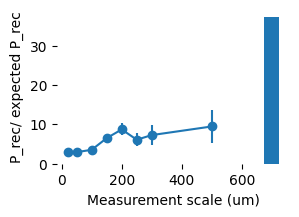

In [7]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(3, 2))
ax = fig.gca()

ax.errorbar(scales, res[:, 0], yerr=res[:, 1], marker='o')
ax.bar([ttl_mean_dist], [ttl_over], width=50)
ax.set_xlabel("Measurement scale (um)")
ax.set_ylabel("P_rec/ expected P_rec")
ax.set_frame_on(False)